<a href="https://colab.research.google.com/github/vishal51512/CEI-internship/blob/main/week5_Vishal_Songara.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [2]:
corpus = '''
The Linux console is a system console internal to the Linux kernel. A system console is the device which receives all kernel messages and warnings and which allows logins in single user mode.[1] The Linux console provides a way for the kernel and other processes to send text output to the user, and to receive text input from the user. The user typically enters text with a computer keyboard and reads the output text on a computer monitor. The Linux kernel supports virtual consoles – consoles that are logically separate, but which access the same physical keyboard and display.[2] The Linux console (and Linux virtual consoles) are implemented by the VT (virtual terminal) subsystem of the Linux kernel, and do not rely on any user space software.[3] This is in contrast to a terminal emulator, which is a user space process that emulates a terminal, and is typically used in a graphical display environment.

The Linux console was one of the first features of the kernel and was originally written by Linus Torvalds in 1991[4] (see history of Linux). There are two main implementations: framebuffer and text mode. The framebuffer implementation is the default in modern Linux distributions, and together with kernel mode setting, provides kernel-level support for display hardware and features such as showing graphics while the system is booting.[5] The legacy text mode implementation was used in PC-compatible systems with CGA, EGA, MDA and VGA graphics cards. Non-x86 architectures used framebuffer mode because their graphics cards did not implement text mode.[5] The Linux console uses fixed-size bitmap, monospace fonts, usually defaulting to 8x16 pixels per character.[5]
'''
print(corpus)


The Linux console is a system console internal to the Linux kernel. A system console is the device which receives all kernel messages and warnings and which allows logins in single user mode.[1] The Linux console provides a way for the kernel and other processes to send text output to the user, and to receive text input from the user. The user typically enters text with a computer keyboard and reads the output text on a computer monitor. The Linux kernel supports virtual consoles – consoles that are logically separate, but which access the same physical keyboard and display.[2] The Linux console (and Linux virtual consoles) are implemented by the VT (virtual terminal) subsystem of the Linux kernel, and do not rely on any user space software.[3] This is in contrast to a terminal emulator, which is a user space process that emulates a terminal, and is typically used in a graphical display environment.

The Linux console was one of the first features of the kernel and was originally writ

# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 139
X shape: (277, 156)
y shape: (277,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [4]:
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [5]:
lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [7]:
gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

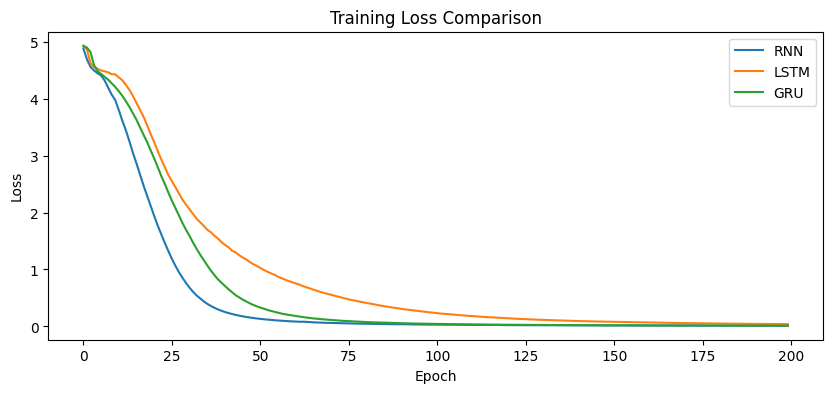

In [8]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [16]:
def generate_text(model, seed_text, next_words = 15):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [17]:
print("RNN :", generate_text(rnn_model, "Linux console", 20))
print("LSTM:", generate_text(lstm_model, "Linux console", 20))
print("GRU :", generate_text(gru_model, "Linux console", 20))

RNN : Linux console was one of the first features of the kernel and was originally written by linus torvalds in 1991 4 see
LSTM: Linux console is a system console internal to the linux kernel a system console is the device which receives all kernel messages
GRU : Linux console is a system console internal to the linux kernel a system console is the device which receives all kernel messages


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**